<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/LangGraph(Nodes_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langgraph

In [2]:
import operator

from IPython.display import Image
from enum import Enum
from langchain_core.runnables import RunnablePassthrough
from langgraph.types import Runnable
from langgraph.graph import END, START, StateGraph
from pathlib import Path
from typing import Annotated, Literal, TypedDict

def display_graph(runnable: Runnable, output_png: Path) -> None:
    graph = runnable.get_graph()

    with output_png.open(mode = "wb") as file:
        file.write(graph.draw_mermaid_png())

    display(Image(output_png, format="png"))

In [7]:
class Category(Enum):
    BILLING = "billing"
    TECHNICAL = "tech"
    SPAM = "spam"

class Priority(Enum):
    LOW = 1
    NORMAL = 2
    HIGH = 3

class Ticket(TypedDict): # Ticket - състоянието на нашата система, всички нодове приемат state: Ticket
    text: str
    category: Category
    priority: Priority
    response: str

## за имплементацията на нодовете е важно да бъдат реализирани като pure функции
всеки един ред код зависи единствено от state който получваме като input

In [11]:
def classify(state: Ticket) -> dict:
    text = state["text"].lower()

    if any(k in text for k in ["refund","invoice", "charge", "payment"]):
        category = Category.BILLING
    elif any(k in text for k in ["crash","bug", "error", "not working"]):
        category = Category.TECHNICAL
    else:
        category = Category.SPAM

    priority: Priority = Priority.HIGH if "urgent" in text or "!!!" in text else Priority.LOW
    print(f"[classify] -> {category} / {priority}")
    return {"category": category, "priority": priority}

def billing(state: Ticket) -> dict:
    return { "response": "Billing: we will review your invoice within 24h." }

def technical(state: Ticket) -> dict:
    return { "response": "Technical: please share the error log; we are on it." }

def reject(state: Ticket) -> dict:
    return { "response": "(auto-rejected as spam)" }

def human_review(state: Ticket) -> dict:
    escalated = state["response"] + " [ESCALATED TO HUMAN AGENT]"
    return { "response": escalated }

In [10]:
def maybe_escalate(state: Ticket) -> str:
    if (state["priority"] == Priority.HIGH or state["priority"] == Priority.NORMAL) and not state["category"] == Category.SPAM:
        return "human_review"
    return END

In [13]:
graph_builder = StateGraph(Ticket) # създаваме инстанция с която казваме state: e Ticket
# регистрираме всички нодове които участват в състава и
graph_builder.add_node("classify", classify)
graph_builder.add_node("billing", billing)
graph_builder.add_node("technical", technical)
graph_builder.add_node("reject", reject)
graph_builder.add_node("human_review", human_review)

# category -> processing_node
processing_nodes_map = { Category.BILLING: "billing", Category.TECHNICAL: "technical", Category.SPAM: "reject" }
processing_nodes_map = { key.value: value for key, value in processing_nodes_map.items() }

# започва от start-> classify
graph_builder.add_edge(START, "classify")
graph_builder.add_conditional_edges("classify", lambda x: x["category"].value, processing_nodes_map)
# подаваме функц lambda x: x["category"].value, която на базата на текущият стейт трябва да прецени кой е следващият node
# взимаме категорията ако е billing=billing, technical=tech

# за billing, reject, technical добавяме conditional_edges с който казваме ако е необходимо humanReview продължи с него, ако не с END
for processing_node in processing_nodes_map.values():
    graph_builder.add_conditional_edges(processing_node, maybe_escalate, ["human_review", END])

graph_builder.add_edge("human_review", END) # Ако се е наложило human_review -> прекратяваме

graph = graph_builder.compile()

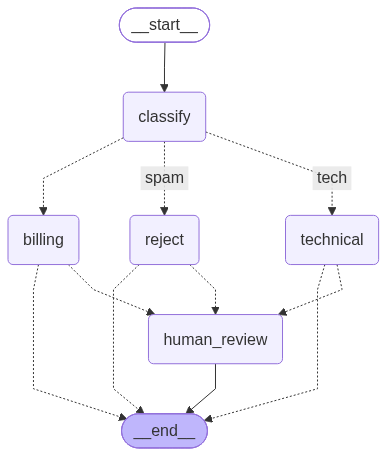

In [14]:
display_graph(graph, Path("/content/graph.png"))

## пунктираната линия с която са свързани нодовете означава че има някакво условие - conditional_edges

In [15]:
examples = [
    "My last invoice has a wrong charge, please refund.",
    "URGENT!!! the app crashes on startup, bug?",
    "Buy cheap watches now"
]

for example in examples:
    print(f">> {example}")

    result = graph.invoke({"text": example})
    print(result["response"])
    print()

>> My last invoice has a wrong charge, please refund.
[classify] -> Category.BILLING / Priority.LOW
Billing: we will review your invoice within 24h.

>> URGENT!!! the app crashes on startup, bug?
[classify] -> Category.TECHNICAL / Priority.HIGH
Technical: please share the error log; we are on it. [ESCALATED TO HUMAN AGENT]

>> Buy cheap watches now
[classify] -> Category.SPAM / Priority.LOW
(auto-rejected as spam)

